# Introduction: the small-area problem

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Data Acquisition →](02_data_acquisition.ipynb)

Direct survey estimates become unpublishably noisy once you slice the Annual Population Survey (APS) to local authorities. This notebook sets out why, and writes down the Fay–Herriot model that official statistics has used for two decades to borrow strength.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'sae_utils.py').exists():
    PROJ_DIR = Path('projects/small-area-estimation').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from sae_utils import (
    load_panel, modelling_frame, design_matrix, eblup_fh, fh_reml_sigma_u,
    jackknife_mse, gibbs_fh, summarise_theta, posterior_predictive_y,
    rhat_split, coverage_rate, project_data_dir,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

FIG_DIR = PROJ_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = project_data_dir()
PANEL = load_panel()
MODEL = modelling_frame(PANEL)
print(f'Panel: {len(PANEL)} local authorities; modelling subset: {len(MODEL)}')
print(f'Period (APS / ONS model-based): {PANEL["direct_period"].dropna().iloc[0]}')


Panel: 348 local authorities; modelling subset: 136
Period (APS / ONS model-based): Apr 2025-Mar 2026


## Why direct estimates fail

The APS is a household survey designed to support **national and regional** labour-market estimates. At local-authority (LA) level the achieved sample in a 12-month window is often a few hundred economically active adults, sometimes fewer. Unemployment is a rare outcome (~4–6% of the economically active), so the **numerator sample** is a handful of people.

Write $y_i$ for the direct Horvitz–Thompson estimator of the unemployment rate $\theta_i$ in area $i$, and $\psi_i = \mathrm{Var}(y_i \mid \theta_i)$ for its design-based sampling variance (treated as known). Then

$$
y_i = \theta_i + e_i, \qquad e_i \sim N(0, \psi_i).
$$

If $\psi_i$ is large relative to the between-area variation in $\theta_i$, the ranking of LAs by $y_i$ is mostly ranking of sampling error. ONS historically responded by **suppressing** estimates with large CVs and, for unemployment specifically, by publishing a **model-based** series instead (Nomis dataset NM_127).

In [2]:
print(PANEL[['direct_rate','direct_rate_ci','psi','cv','ons_mb_rate']].describe().round(3).to_string())
print('\nShare of LAs with a published APS rate: '
      f"{PANEL['direct_rate'].notna().mean():.0%}")
print(f"Share with a published 95% CI (modelling inputs): {PANEL['psi'].notna().mean():.0%}")


       direct_rate  direct_rate_ci      psi       cv  ons_mb_rate
count      284.000         136.000  136.000  136.000      348.000
mean         4.792           2.448    1.694    0.235        4.174
std          2.010           0.721    1.023    0.044        1.222
min          1.300           1.100    0.315    0.126        1.700
25%          3.375           2.000    1.041    0.204        3.300
50%          4.300           2.300    1.377    0.235        3.900
75%          5.925           2.900    2.189    0.268        4.800
max         14.000           4.500    5.271    0.329        8.800

Share of LAs with a published APS rate: 82%
Share with a published 95% CI (modelling inputs): 39%


## Fay–Herriot intuition

The linking model assumes the true rates vary smoothly with auxiliary information $x_i$ that is known without (or with negligible) sampling error. ONS uses the **claimant count** — an administrative register — as the workhorse covariate, because it is strongly correlated with ILO unemployment and has no survey variance:

$$
\theta_i = x_i'\beta + u_i, \qquad u_i \sim N(0, \sigma_u^2).
$$

The EBLUP is a convex combination of the direct estimate and the regression synthetic estimator $\hat{\theta}_i^{\mathrm{syn}} = x_i'\hat\beta$:

$$
\hat{\theta}_i^{\mathrm{EBLUP}} = \gamma_i y_i + (1-\gamma_i) x_i'\hat\beta, \qquad \gamma_i = \frac{\sigma_u^2}{\sigma_u^2 + \psi_i}.
$$

Areas with small $\psi_i$ (large samples) keep $\gamma_i \approx 1$ and barely shrink; noisy areas are pulled toward the regression surface. That is the whole idea — **shrinkage in proportion to sampling variance**, not a uniform smooth.

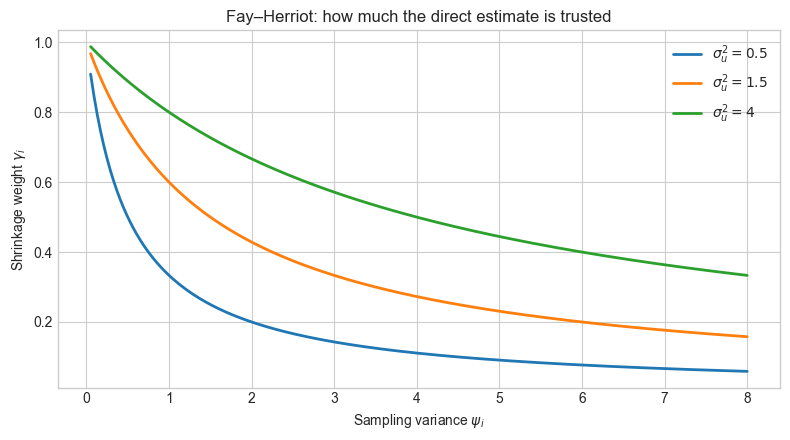

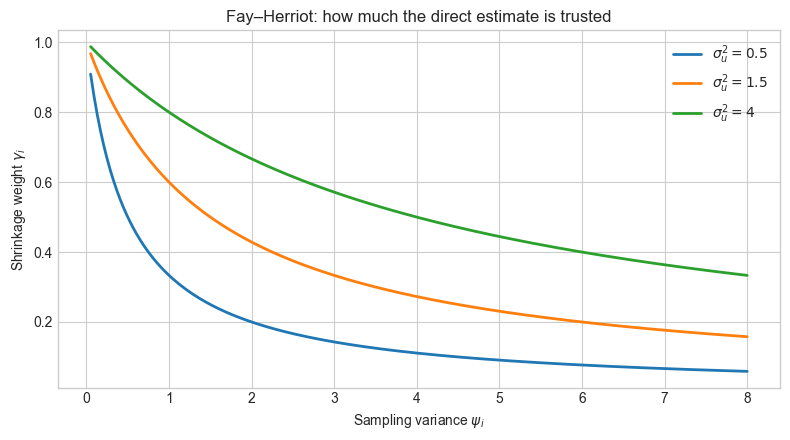

In [3]:
# Schematic: shrinkage as a function of sampling variance, holding σ²_u fixed
psi_grid = np.linspace(0.05, 8, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
for s2, lab in [(0.5, r'$\sigma_u^2 = 0.5$'), (1.5, r'$\sigma_u^2 = 1.5$'), (4.0, r'$\sigma_u^2 = 4$')]:
    ax.plot(psi_grid, s2 / (s2 + psi_grid), label=lab, lw=2)
ax.set_xlabel(r'Sampling variance $\psi_i$')
ax.set_ylabel(r'Shrinkage weight $\gamma_i$')
ax.set_title('Fay–Herriot: how much the direct estimate is trusted')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '01_shrinkage_weight.png', dpi=120)
fig


## Two inferential routes

| | Classical EBLUP | Bayesian hierarchical |
|---|---|---|
| $\sigma_u^2$ | Point estimate (REML / Prasad–Rao MOM) | Full posterior |
| $\theta_i$ | Plug-in EBLUP + analytic or jackknife MSE | Posterior mean / median and credible interval |
| Uncertainty in $\hat\beta, \hat\sigma_u^2$ | Corrected for via $g_1+g_2+2g_3$ (Datta–Lahiri) | Propagated automatically |
| Assumptions | Frequentist MSE under the model; $\psi_i$ known | Prior on $\beta, \sigma_u^2$; same sampling model |

Neither is a free lunch. The frequentist MSE approximations are **asymptotic in the number of areas**, not in the sample size per area, and they treat $\psi_i$ as known (it is estimated from the survey). The Bayesian interval is well-calibrated only if the prior and the linking model are adequate. We will stress-test both against ONS's published model-based figures — which are themselves a production Fay–Herriot, not ground truth.

## What this project is not

- It is **not** the ONS production pipeline. ONS has used variants with benchmarking to regional APS totals, time-series linking, and (in some years) more elaborate covariance structures. We implement the textbook area-level model on public aggregates.
- It does **not** use APS microdata. All inputs are LA-level Nomis tables under the Open Government Licence.
- $\psi_i$ is recovered from published 95% CI half-widths as $(c_i / 1.96)^2$. That ignores uncertainty in the variance estimate itself.

## Key takeaways

- Direct APS unemployment rates at LA level are often suppressed or have CVs too large to support rankings.
- Fay–Herriot shrinks $y_i$ toward $x_i'\beta$ with weight $\gamma_i$ determined by the **ratio** of process variance to sampling variance.
- ONS model-based estimates are the natural external benchmark for an open-source reimplementation — agreement is a check, not a proof.

---

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Data Acquisition →](02_data_acquisition.ipynb)
